# Learning PES with Gaussian Process Regression (GPR) and SOAP Features
In this lab, we repeat the learning task in Lab 9-1, but now using a different set of ML model + feature engineering method.

We use the same pacakge.

In [5]:
! pip install -q torch-geometric dscribe py3Dmol

In [6]:
from dscribe.descriptors import SOAP
from torch_geometric.datasets import MD17
from ase import Atoms
import numpy as np
import random

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

#
from matplotlib import pyplot as plt

## Repeat acquiring data and extracting information.

In [7]:
dataset = MD17(root="lab9/MD17", name='ethanol') # root is where we save the downloaded data, name is the name used to querry the MD trajectories.
n_data = len(dataset)
print("Number of MD frames for ethanol:", n_data)

Number of MD frames for ethanol: 555092


In [8]:
# randomly sample 200 frames from the dataset to train our teeny-tiny neural network
n_sample = 200
indices = random.sample(range(n_data), n_sample) # no duplicate
frames = [dataset[i] for i in indices]

# convert to ASE atoms
frame_list = []
energies = []
forces_list = []
for frame in frames:
    numbers = frame.z.numpy()
    pos = frame.pos.numpy()
    energy = frame.energy.item()
    force = frame.force.numpy()
    atoms = Atoms(numbers=numbers, positions=pos) # a molecule
    frame_list.append(atoms)
    energies.append(energy)
    forces_list.append(force)

energies = np.array(energies)
forces_list = np.array(forces_list)

## Construct SOAP features

In [9]:
species = ["H", "C", "O"]  # your molecule composition
soap = SOAP(
    species=species,
    r_cut=6.0,
    n_max=4,
    l_max=4,
    sigma=0.3,
    periodic=False,
)

X = np.array([soap.create(frame) for frame in frame_list])  # shape: (n_frames, n_atoms, n_features)
print("Feature shape: ", X.shape)
X = X.reshape(len(frame_list), -1)  # flatten per-frame for GPR
print("Flattened feature shape: ",X.shape)
# the number is different from our lecture prediction because of the crossover feature in SOAP: https://singroup.github.io/dscribe/0.3.x/_modules/dscribe/descriptors/soap.html

Feature shape:  (200, 9, 390)
Flattened feature shape:  (200, 3510)


## Extract y values

In [10]:
y = np.array(energies)  # shape: (n_frames,)

### Train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### GPR

In [12]:
# Kernel: RBF + White noise
kernel = RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10.0)) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True) # regularization
gpr.fit(X_train, y_train)

GaussianProcessRegressor(alpha=0.0,
                         kernel=RBF(length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True)

### Evaluate

In [13]:
y_pred, y_std = gpr.predict(X_test, return_std=True)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.4f} eV")


Test MAE: 3.3095 eV


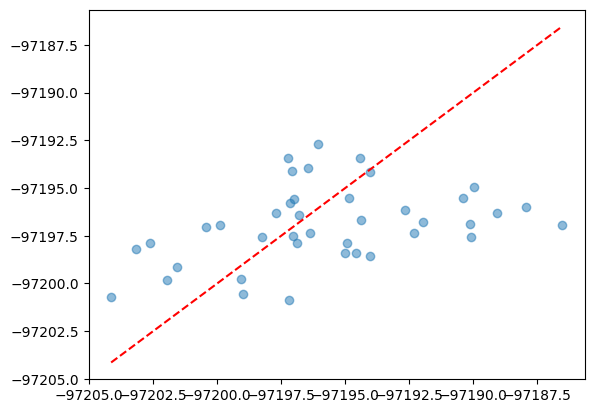

In [14]:
plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], '--', c='r')
plt.scatter(y_test, y_pred, alpha=0.5)